source: https://github.com/nytimes/presidential-precinct-map-2024?tab=readme-ov-file

Each precinct in the data has the following properties:

**state**: state postal abbreviation

**GEOID**: unique identifier for the precinct, formed from the five-digit county F.I.P.S. code followed by the precinct name/ID (e.g., 30003-08 or 39091-WEST MANSFIELD)

**votes_dem**: votes received by Kamala Harris

**votes_rep**: votes received by Donald J. Trump

**votes_total**: total votes in the precinct, including for third-party candidates and write-ins when available

**pct_dem_lead**: (votes_dem - votes_rep) / (votes_total), with four significant digits (e.g., -0.2134)

**official_boundary**: true if the precinct’s shape came from a file that was provided by the state or county, false if the precinct boundary was estimated (see caveats below)

In [2]:
import pandas as pd
import numpy as np
import geopandas

In [3]:
df = geopandas.read_file("../data/Delaware/Precinct/de_nyt.geojson")

In [4]:
print(f"shape:{df.shape}")
df.head()

shape:(526, 8)


,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,DE,10001-11-05,521,1116,1665,-0.3574,True,"POLYGON ((-75.6658 39.29057, -75.66581 39.2905..."
1,DE,10001-11-06,332,990,1345,-0.4892,True,"POLYGON ((-75.75449 39.22743, -75.75449 39.227..."
2,DE,10001-11-07,158,284,449,-0.2806,True,"POLYGON ((-75.69349 39.19968, -75.6935 39.1996..."
3,DE,10001-11-08,194,431,635,-0.3732,True,"POLYGON ((-75.64732 39.15437, -75.64734 39.154..."
4,DE,10001-11-09,89,280,373,-0.5121,True,"POLYGON ((-75.74776 39.14335, -75.74776 39.143..."


In [6]:
df = df.sort_values(by="GEOID")

In [8]:
df

,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,DE,10001-11-05,521,1116,1665,-0.3574,True,"POLYGON ((-75.6658 39.29057, -75.66581 39.2905..."
1,DE,10001-11-06,332,990,1345,-0.4892,True,"POLYGON ((-75.75449 39.22743, -75.75449 39.227..."
2,DE,10001-11-07,158,284,449,-0.2806,True,"POLYGON ((-75.69349 39.19968, -75.6935 39.1996..."
3,DE,10001-11-08,194,431,635,-0.3732,True,"POLYGON ((-75.64732 39.15437, -75.64734 39.154..."
4,DE,10001-11-09,89,280,373,-0.5121,True,"POLYGON ((-75.74776 39.14335, -75.74776 39.143..."
...,...,...,...,...,...,...,...,...
520,DE,10005-41-10,320,424,756,-0.1376,True,"POLYGON ((-75.23551 38.48005, -75.23551 38.480..."
521,DE,10005-41-11,378,812,1199,-0.3620,True,"POLYGON ((-75.19192 38.47895, -75.19193 38.478..."
522,DE,10005-41-12,115,317,441,-0.4580,True,"POLYGON ((-75.18948 38.48168, -75.18857 38.482..."
523,DE,10005-41-13,249,469,722,-0.3047,True,"POLYGON ((-75.19192 38.47895, -75.19191 38.478..."


In [11]:
offical_boundry = df['official_boundary'].unique()
offical_boundry

array([ True])

<Axes: >

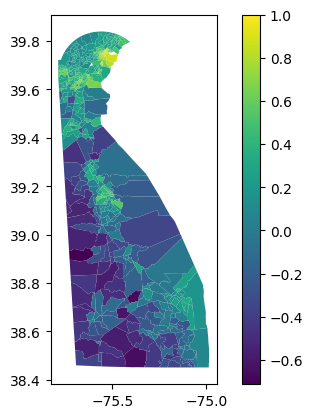

In [9]:
df.plot(column="pct_dem_lead", legend=True)